In [1]:
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from matplotlib.ticker import PercentFormatter


DATA_DIR = Path('../data')

In [2]:
from osf import sync_osf
csv_files = sync_osf(DATA_DIR / "raw")

Synced 51 CSV files from OSF to ../data/raw


In [3]:
csv_files = glob.glob(f'{DATA_DIR}/raw/*.csv')

In [4]:
sessions = [pd.read_csv(f) for f in csv_files]
kept_columns = ['random_id', 'chunk_length', 'chunk', 'rt', 'round_index', 'bot_move', 'player_move', 'policy_phase', 'outcome']
valid_sessions = []

for df_tidy, fname in zip(sessions, csv_files):
    scored_rounds = df_tidy.loc[(df_tidy['task_phase'] == 'rps') & (df_tidy['practice'] == False)]
    if scored_rounds.shape[0] < 100:
        print(f'Skipping {fname}')
        continue
    session = scored_rounds[kept_columns]
    
    valid_sessions.append(session)

df_tidy = pd.concat(valid_sessions, ignore_index=True)

# Cast to appropriate dtypes
column_dtypes = {
    'round_index': int,
    'policy_phase': int,
}

df_tidy = df_tidy.astype(column_dtypes)
df_tidy['won'] = df_tidy['outcome'].map({'win': True, 'loss': False})
df_tidy = df_tidy.drop('outcome', axis=1)

display(df_tidy.head())
display(df_tidy.describe())

,random_id,chunk_length,chunk,rt,round_index,bot_move,player_move,policy_phase,won
0,dl0qsocc4e,4,prsr,1468.0,1,p,s,0,True
1,dl0qsocc4e,4,prsr,712.0,2,r,s,1,False
2,dl0qsocc4e,4,prsr,1034.0,3,s,s,2,False
3,dl0qsocc4e,4,prsr,769.0,4,r,p,3,True
4,dl0qsocc4e,4,prsr,723.0,5,p,p,0,False


,chunk_length,rt,round_index,policy_phase
count,5100.000000,4977.000000,5100.0000,5100.000000
mean,3.470588,806.067511,50.5000,0.800000
std,1.143772,735.165387,28.8689,1.129921
min,2.000000,1.000000,1.0000,0.000000
25%,2.000000,287.000000,25.7500,0.000000
50%,3.000000,476.000000,50.5000,0.000000
75%,5.000000,1124.000000,75.2500,1.000000
max,5.000000,2992.000000,100.0000,4.000000


In [26]:
# Remove any participants with unrealistic data
MAX_POLICY_ACC = 0.95

df = df_tidy.copy()

mean_rt = df.groupby('random_id')['rt'].mean()
extreme_rt_ids = mean_rt[(mean_rt < 150) | (mean_rt > 2500)].index
df = df[~df['random_id'].isin(extreme_rt_ids)]
print(f"Removed {len(extreme_rt_ids)} participants with mean rt < 150")

move_counts = df.groupby('random_id')['player_move'].nunique()
low_move_var_ids = move_counts[move_counts < 3].index
df = df[~df['random_id'].isin(low_move_var_ids)]
print(f"Removed {len(low_move_var_ids)} participants using fewer than 3 moves")

mean_acc = df.loc[df['policy_phase'] > 0].groupby('random_id')['won'].mean()

high_acc_ids = mean_acc[mean_acc > MAX_POLICY_ACC].index
df = df[~df['random_id'].isin(high_acc_ids)]
print(f"Removed {len(high_acc_ids)} participants with greater than {MAX_POLICY_ACC} mean accuracy")

Removed 2 participants with mean rt < 150
Removed 0 participants using fewer than 3 moves
Removed 2 participants with greater than 0.95 mean accuracy


In [27]:
df.to_csv(f'{DATA_DIR}/clean.csv', index=False)

In [28]:
# Filter the dataframe by rounds during which the participant
# passed a threshold minimum mean accuracy
# (i.e. had "learned" the hidden policy)

BURN_ROUNDS = 50
ACC_THRESHOLD = 0.7

df_latter = df.loc[df['round_index'] > BURN_ROUNDS].copy()
latter_acc = df_latter.loc[df['policy_phase'] > 0].groupby('random_id')['won'].mean()
latter_acc_hi = latter_acc[latter_acc > ACC_THRESHOLD]
hiacc_ids = latter_acc_hi.index
df_hiacc = df.loc[df['random_id'].isin(hiacc_ids)].copy()

print(df_hiacc['random_id'].nunique())

df_hiacc.to_csv(DATA_DIR / 'hiacc.csv', index=False)

10


/Users/dan/venv/cogs180/.venv/lib/python3.14/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/dan/venv/cogs180/.venv/lib/python3.14/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/dan/venv/cogs180/.venv/lib/python3.14/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/dan/venv/cogs180/.venv/lib/python3.14/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/dan/venv/cogs180/.venv/lib/python3.14/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/dan/venv/cogs180/.venv/lib/python3.14/site-packages/seaborn/reg

Text(0.5, 1.0, 'Reaction time vs. chunk length')

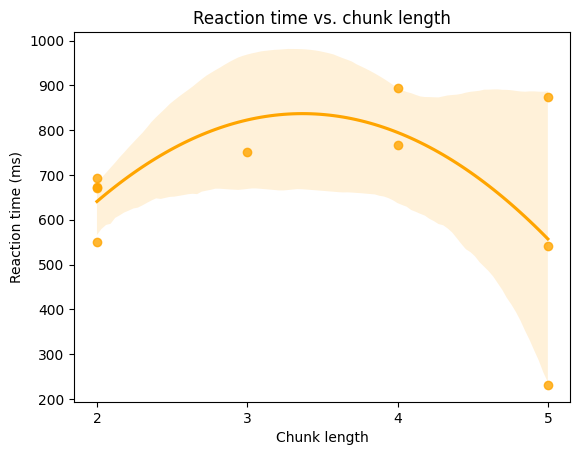

In [37]:
chunk_lengths_hi = df_hiacc.groupby('random_id')['chunk_length'].first()
rt_hi = df_hiacc.groupby('random_id')['rt'].mean()

ax = sns.regplot(x=chunk_lengths_hi, y=rt_hi, order=2, color='orange')
ax.set_xticks(range(2, 6))
ax.set_xlabel("Chunk length")
ax.set_ylabel("Reaction time (ms)")
ax.set_title("Reaction time vs. chunk length")

In [36]:
cl_vs_rt = smf.ols('rt ~ chunk_length + I(chunk_length**2)', data={
    'rt': rt_hi,
    'chunk_length': chunk_lengths_hi,
}).fit()

cl_vs_rt.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     rt   R-squared:                       0.289
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     1.422
Date:                Sun, 15 Mar 2026   Prob (F-statistic):              0.303
Time:                        20:49:31   Log-Likelihood:                -64.532
No. Observations:                  10   AIC:                             135.1
Df Residuals:                       7   BIC:                             136.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             -352.6753    676.846     -0.521      0.618   -1953.161    1247.811
chunk_length           706.5359    443.630      1.593      0.155    -342.482    1755.553
I(chunk_length ** 2)  -104.9136     63.935     -1.641      0.145    -256.096      46.269
==============================================================================
Omnibus:                        2.790   Durbin-Watson:                   1.672
Prob(Omnibus):                  0.248   Jarque-Bera (JB):                0.336
Skew:                          -0.070   Prob(JB):                        0.845
Kurtosis:                       3.887   Cond. No.                         228.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Text(0.5, 1.0, 'Accuracy vs. chunk length')

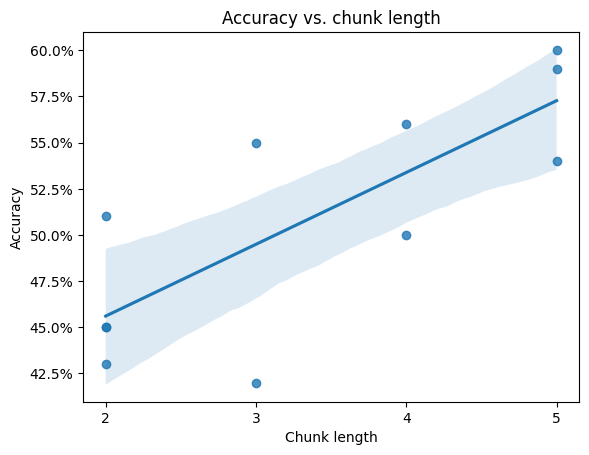

In [10]:
acc_hi = df_hiacc.groupby('random_id')['won'].mean()
acc_vs_cl = sns.regplot(x=chunk_lengths_hi, y=acc_hi)
acc_vs_cl.set_xticks(range(2, 6))
acc_vs_cl.yaxis.set_major_formatter(PercentFormatter(1.0))
acc_vs_cl.set_xlabel("Chunk length")
acc_vs_cl.set_ylabel("Accuracy")
acc_vs_cl.set_title("Accuracy vs. chunk length")


In [11]:
cl_vs_acc = smf.ols('acc_hi ~ chunk_length', data={
    'acc_hi': acc_hi,
    'chunk_length': chunk_lengths_hi,
}).fit()

cl_vs_acc.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 acc_hi   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.563
Method:                 Least Squares   F-statistic:                     13.86
Date:                Sun, 15 Mar 2026   Prob (F-statistic):            0.00474
Time:                        20:00:46   Log-Likelihood:                 20.237
No. Observations:                  11   AIC:                            -36.47
Df Residuals:                       9   BIC:                            -35.68
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.3782      0.037     10.112      0.000       0.294       0.463
chunk_length     0.0389      0.010      3.724      0.005       0.015       0.063
==============================================================================
Omnibus:                        0.232   Durbin-Watson:                   1.486
Prob(Omnibus):                  0.890   Jarque-Bera (JB):                0.381
Skew:                          -0.233   Prob(JB):                        0.827
Kurtosis:                       2.217   Cond. No.                         11.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

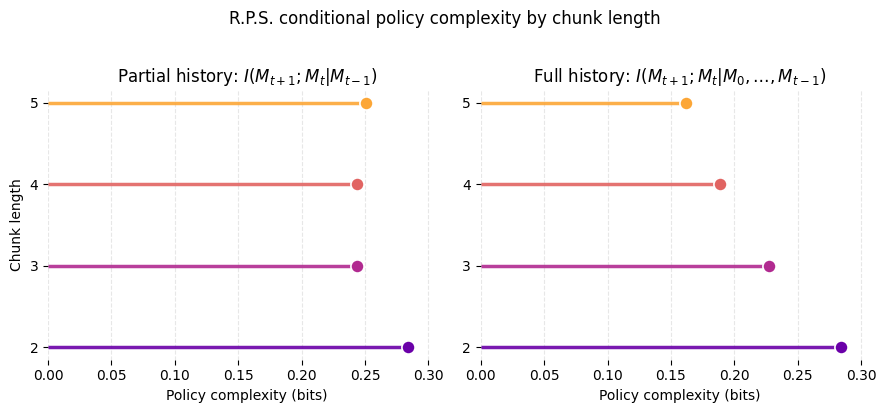

In [12]:
# Policy complexity (as a function of chunk length) conditioned on
#   - partial history (len(h) = 1)
#   - full history (len(h) = inf)

chunk_lengths = np.array(range(2, 6))
cpc_h1 = np.array([0.284, 0.244, 0.244, 0.251])
cpc_hinf = np.array([0.284, 0.227, 0.189, 0.162])

palette = sns.color_palette("plasma", n_colors=len(chunk_lengths))
colors = dict(zip(chunk_lengths, palette))
xmax = max(cpc_h1.max(), cpc_hinf.max()) + 0.03

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
series = [
    (axes[0], cpc_h1, r"Partial history: $I(M_{t+1};M_t|M_{t-1})$"),
    (axes[1], cpc_hinf, r"Full history: $I(M_{t+1};M_t|M_0, \ldots, M_{t-1})$"),
]

for ax, values, title in series:
    for y, x in zip(chunk_lengths, values):
        ax.hlines(y=y, xmin=0, xmax=x, color=colors[y], linewidth=2.5, alpha=0.9)
        ax.scatter(x, y, s=90, color=colors[y], edgecolor="white", linewidth=1.2, zorder=3)

    ax.set_title(title)
    ax.set_xlim(0, xmax)
    ax.set_xlabel("Policy complexity (bits)")
    ax.grid(axis="x", linestyle="--", alpha=0.3)

axes[0].set_ylabel("Chunk length")
axes[0].set_yticks(chunk_lengths)
axes[0].set_yticklabels(chunk_lengths)
axes[1].tick_params(axis="y", labelleft=True)
axes[1].set_yticks(chunk_lengths)
axes[1].set_yticklabels(chunk_lengths)

sns.despine(left=True, bottom=True)
fig.suptitle("R.P.S. conditional policy complexity by chunk length", y=1.02)
fig.tight_layout()
